In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
import pandas as pd

data = {
    "Product": ["Laptop", "Phone", "Chair", "Laptop", "Table"],
    "Category": ["Electronics", "Electronics", "Furniture", "Electronics", "Furniture"],
    "Quantity": [2, 5, 4, 1, 3],
    "Sales": [100000, 75000, 20000, 50000, 30000]
}

df = pd.DataFrame(data)

df

,Product,Category,Quantity,Sales
0,Laptop,Electronics,2,100000
1,Phone,Electronics,5,75000
2,Chair,Furniture,4,20000
3,Laptop,Electronics,1,50000
4,Table,Furniture,3,30000


In [ ]:
df = pd.read_csv("/content/superstore.csv", engine='python', on_bad_lines='skip', delimiter=';')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (8394, 21)


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [ ]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost', 'Customer Name', 'Province', 'Region', 'Customer Segment', 'Product Category', 'Product Sub-Category', 'Product Name', 'Product Container', 'Product Base Margin', 'Ship Date']


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8394
Number of columns: 21


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Order Priority,0
Order Quantity,0
Sales,0
Discount,0
Ship Mode,0
Profit,0
Unit Price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes


,0
Row ID,int64
Order ID,int64
Order Date,object
Order Priority,object
Order Quantity,int64
Sales,float64
Discount,float64
Ship Mode,object
Profit,float64
Unit Price,float64


In [ ]:
print(df.columns.tolist())
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Date"].dtype
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df[["Order Date", "Year", "Month", "Month_Name"]].head()




['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost', 'Customer Name', 'Province', 'Region', 'Customer Segment', 'Product Category', 'Product Sub-Category', 'Product Name', 'Product Container', 'Product Base Margin', 'Ship Date', 'Year', 'Month', 'Month_Name']


,Order Date,Year,Month,Month_Name
0,2010-10-13,2010,10,October
1,2012-10-01,2012,10,October
2,2012-10-01,2012,10,October
3,2011-07-10,2011,7,July
4,2010-08-28,2010,8,August


In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum()

print(monthly_sales)
yearly_sales = df.groupby("Year")["Sales"].sum()

print(yearly_sales)


Month
1     1.444772e+06
2     1.180084e+06
3     1.273681e+06
4     1.216483e+06
5     1.160749e+06
6     1.030809e+06
7     1.141104e+06
8     1.115015e+06
9     1.337957e+06
10    1.383714e+06
11    1.163393e+06
12    1.467378e+06
Name: Sales, dtype: float64
Year
2009    4.208988e+06
2010    3.549482e+06
2011    3.436708e+06
2012    3.719964e+06
Name: Sales, dtype: float64


In [ ]:
category_sales = df.groupby("Product Category")["Sales"].sum()

print(category_sales)
category_sales = category_sales.sort_values(ascending=False)

print(category_sales)

Product Category
Furniture          5178590.542
Office Supplies    3752302.630
Technology         5984248.182
Name: Sales, dtype: float64
Product Category
Technology         5984248.182
Furniture          5178590.542
Office Supplies    3752302.630
Name: Sales, dtype: float64


In [ ]:
category_profit = df.groupby("Product Category")["Profit"].sum()

print(category_profit.sort_values(ascending=False))

Product Category
Technology         886313.52
Office Supplies    517999.39
Furniture          117433.03
Name: Profit, dtype: float64


In [ ]:
region_sales = df.groupby("Region")["Sales"].sum()

print(region_sales.sort_values(ascending=False))

Region
West                     3.597449e+06
Ontario                  3.062914e+06
Prarie                   2.837305e+06
Atlantic                 2.014188e+06
Quebec                   1.510195e+06
Yukon                    9.758674e+05
Northwest Territories    8.008473e+05
Nunavut                  1.163765e+05
Name: Sales, dtype: float64


In [ ]:
region_profit = df.groupby("Region")["Profit"].sum()

print(region_profit.sort_values(ascending=False))

Region
Ontario                  346846.08
Prarie                   321160.12
West                     297009.97
Atlantic                 238959.72
Quebec                   140426.65
Northwest Territories    100653.08
Yukon                     73849.21
Nunavut                    2841.11
Name: Profit, dtype: float64


In [ ]:
top_products = df.groupby("Product Name")["Sales"].sum()

print(top_products.sort_values(ascending=False).head(10))

Product Name
Global Troy™ Executive Leather Low-Back Tilter                   275941.520
Polycom ViewStation™ ISDN Videoconferencing Unit                 255303.970
Canon PC940 Copier                                               210910.680
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish    206494.130
Hewlett Packard LaserJet 3310 Copier                             194880.350
Bretford CR8500 Series Meeting Room Furniture                    147412.212
Sharp AL-1530CS Digital Copier                                   130046.810
Hewlett-Packard cp1700 [D, PS] Series Color Inkjet Printers      128100.430
GBC DocuBind 200 Manual Binding Machine                          120342.740
Canon imageCLASS 2200 Advanced Copier                            114173.410
Name: Sales, dtype: float64


In [ ]:
correlation = df[["Sales", "Profit", "Discount", "Order Quantity"]].corr()

print(correlation)

                   Sales    Profit  Discount  Order Quantity
Sales           1.000000  0.581961 -0.019460        0.220627
Profit          0.581961  1.000000 -0.037065        0.194696
Discount       -0.019460 -0.037065  1.000000       -0.009497
Order Quantity  0.220627  0.194696 -0.009497        1.000000


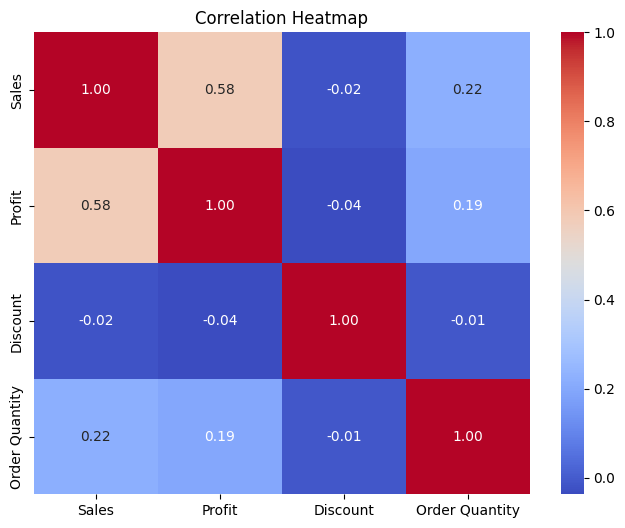

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

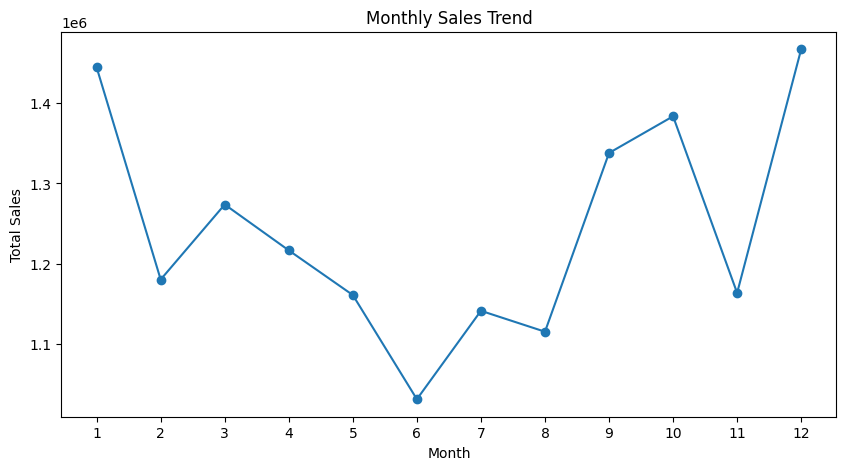

In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))

plt.show()

In [ ]:
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day
df["Day_of_Week"] = df["Order Date"].dt.dayofweek

df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Product Name,Product Container,Product Base Margin,Ship Date,Year,Month,Month_Name,Quarter,Day,Day_of_Week
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010,2010,10,October,4,13,2
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012,2012,10,October,4,1,0
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012,2012,10,October,4,1,0
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,R380,Small Box,0.58,7/12/2011,2011,7,July,3,10,6
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010,2010,8,August,3,28,5


In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,int64
Order Date,datetime64[ns]
Order Priority,object
Order Quantity,int64
Sales,float64
Discount,float64
Ship Mode,object
Profit,float64
Unit Price,float64


In [ ]:
features = [
    "Order Priority",
    "Order Quantity",
    "Discount",
    "Ship Mode",
    "Unit Price",
    "Shipping Cost",
    "Province",
    "Region",
    "Customer Segment",
    "Product Category",
    "Product Sub-Category",
    "Product Container",
    "Product Base Margin",
    "Year",
    "Month",
    "Quarter",
    "Day",
    "Day_of_Week"
]

X = df[features]
y = df["Sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8394, 18)
y shape: (8394,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = [
    "Order Priority",
    "Ship Mode",
    "Province",
    "Region",
    "Customer Segment",
    "Product Category",
    "Product Sub-Category",
    "Product Container"
]

# Identify numerical features
numerical_features = [col for col in features if col not in categorical_features]

# Create a pipeline for numerical features to handle imputation
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')) # Impute missing numerical values with the mean
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (8394, 18)
Encoded X shape: (8394, 70)


In [ ]:
df = df.sort_values("Order Date").reset_index(drop=True)

X = df[features]
y = df["Sales"]

X_encoded = preprocessor.fit_transform(X)

split_index = int(len(df) * 0.8)

X_train = X_encoded[:split_index]
X_test = X_encoded[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6715, 70)
Testing data: (1679, 70)


In [ ]:
# Split raw data first
X_train_raw = X.iloc[:split_index]
X_test_raw = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Fit encoder only on training data
X_train = preprocessor.fit_transform(X_train_raw)

# Apply the same encoder to test data
X_test = preprocessor.transform(X_test_raw)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6715, 70)
Testing data: (1679, 70)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
# Make predictions on test data
y_pred = model.predict(X_test)

print("Predictions completed successfully!")
print("First 10 predicted sales:")
print(y_pred[:10])

Predictions completed successfully!
First 10 predicted sales:
[  57.43465     43.5680575 9446.42539    306.4604425  237.466
  358.50066    201.33995     11.56      2553.686225   287.84425  ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 131.85263000148913
RMSE: 519.9889205716497
R²  : 0.9758324090976132


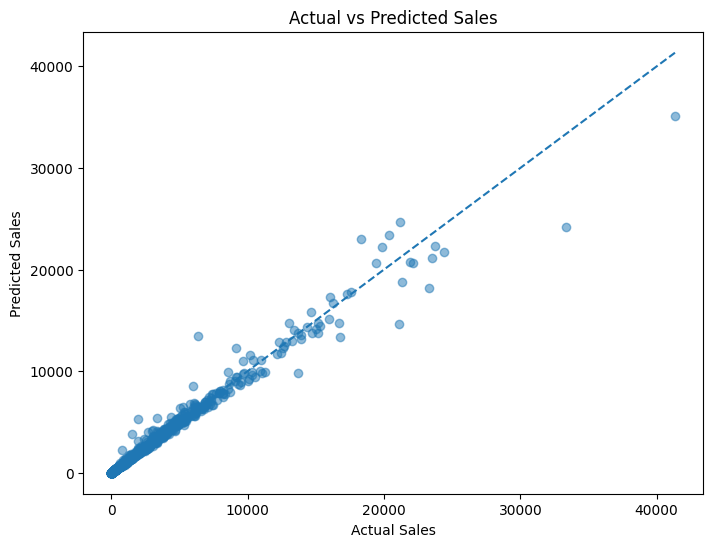

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

In [ ]:
# Create monthly sales data
df["Order Date"] = pd.to_datetime(df["Order Date"])
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
      .reset_index()
)

# Convert month to datetime
monthly_sales["Order Date"] = monthly_sales["Order Date"].astype('datetime64[ns]')

print(monthly_sales.head())
print("\nNumber of months:", len(monthly_sales))

  Order Date        Sales
0 2009-01-01  516151.6095
1 2009-02-01  332480.6365
2 2009-03-01  411628.7290
3 2009-04-01  393276.4820
4 2009-05-01  230145.5380

Number of months: 48


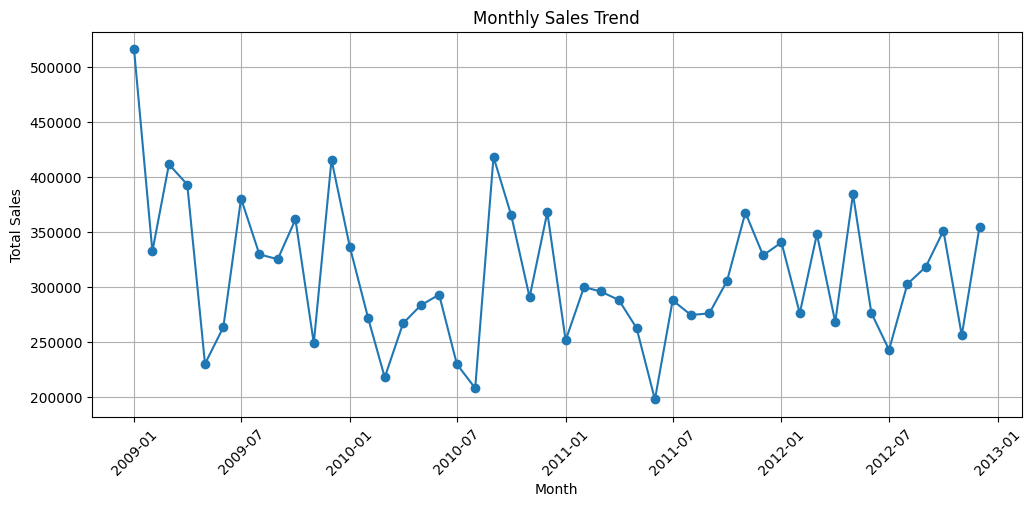

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Create previous month's sales
monthly_sales["lag_1"] = monthly_sales["Sales"].shift(1)

print(monthly_sales.head())

  Order Date        Sales        lag_1
0 2009-01-01  516151.6095          NaN
1 2009-02-01  332480.6365  516151.6095
2 2009-03-01  411628.7290  332480.6365
3 2009-04-01  393276.4820  411628.7290
4 2009-05-01  230145.5380  393276.4820


In [ ]:
# Create additional forecasting features

monthly_sales["lag_3"] = monthly_sales["Sales"].shift(3)
monthly_sales["lag_12"] = monthly_sales["Sales"].shift(12)

monthly_sales["rolling_3"] = (
    monthly_sales["Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

print(monthly_sales.head(15))

   Order Date        Sales        lag_1        lag_3       lag_12  \
0  2009-01-01  516151.6095          NaN          NaN          NaN   
1  2009-02-01  332480.6365  516151.6095          NaN          NaN   
2  2009-03-01  411628.7290  332480.6365          NaN          NaN   
3  2009-04-01  393276.4820  411628.7290  516151.6095          NaN   
4  2009-05-01  230145.5380  393276.4820  332480.6365          NaN   
5  2009-06-01  263456.0680  230145.5380  411628.7290          NaN   
6  2009-07-01  380503.9700  263456.0680  393276.4820          NaN   
7  2009-08-01  329754.7150  380503.9700  230145.5380          NaN   
8  2009-09-01  325292.3145  329754.7150  263456.0680          NaN   
9  2009-10-01  361555.2665  325292.3145  380503.9700          NaN   
10 2009-11-01  248933.4260  361555.2665  329754.7150          NaN   
11 2009-12-01  415809.3505  248933.4260  325292.3145          NaN   
12 2010-01-01  336526.6805  415809.3505  361555.2665  516151.6095   
13 2010-02-01  271580.5080  336526

In [ ]:
# Remove rows with missing forecasting features
forecast_df = monthly_sales.dropna().copy()

print("Original rows:", len(monthly_sales))
print("Rows after removing NaN:", len(forecast_df))

print("\nMissing values:")
print(forecast_df.isnull().sum())

Original rows: 48
Rows after removing NaN: 36

Missing values:
Order Date    0
Sales         0
lag_1         0
lag_3         0
lag_12        0
rolling_3     0
dtype: int64


In [ ]:
# Define forecasting features
forecast_features = [
    "lag_1",
    "lag_3",
    "lag_12",
    "rolling_3"
]

X_forecast = forecast_df[forecast_features]
y_forecast = forecast_df["Sales"]

print("X shape:", X_forecast.shape)
print("y shape:", y_forecast.shape)
print("\nFeatures:")
print(X_forecast.head())

X shape: (36, 4)
y shape: (36,)

Features:
          lag_1        lag_3       lag_12      rolling_3
12  415809.3505  361555.2665  516151.6095  342099.347667
13  336526.6805  248933.4260  332480.6365  333756.485667
14  271580.5080  415809.3505  411628.7290  341305.513000
15  217808.0065  336526.6805  393276.4820  275305.065000
16  266968.5890  271580.5080  230145.5380  252119.034500


In [ ]:
# Time-based train/test split

split_index = int(len(forecast_df) * 0.8)

X_train_forecast = X_forecast.iloc[:split_index]
X_test_forecast = X_forecast.iloc[split_index:]

y_train_forecast = y_forecast.iloc[:split_index]
y_test_forecast = y_forecast.iloc[split_index:]

print("Training data:", X_train_forecast.shape)
print("Testing data:", X_test_forecast.shape)

print("\nTraining period:")
print(forecast_df["Order Date"].iloc[:split_index].min(),
      "to",
      forecast_df["Order Date"].iloc[:split_index].max())

print("\nTesting period:")
print(forecast_df["Order Date"].iloc[split_index:].min(),
      "to",
      forecast_df["Order Date"].iloc[split_index:].max())

Training data: (28, 4)
Testing data: (8, 4)

Training period:
2010-01-01 00:00:00 to 2012-04-01 00:00:00

Testing period:
2012-05-01 00:00:00 to 2012-12-01 00:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create forecasting model
forecast_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
forecast_model.fit(
    X_train_forecast,
    y_train_forecast
)

print("Future sales forecasting model trained successfully!")

Future sales forecasting model trained successfully!


In [ ]:
y_pred_forecast = forecast_model.predict(X_test_forecast)

print("Future sales predictions generated successfully!")
print("\nPredicted sales:")
print(y_pred_forecast)

Future sales predictions generated successfully!

Predicted sales:
[285199.1221875 300361.7497    301845.3429825 271596.8597675
 292710.06514   320000.46527   305100.0616925 256136.249765 ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate forecasting metrics
mae_forecast = mean_absolute_error(
    y_test_forecast,
    y_pred_forecast
)

mse_forecast = mean_squared_error(
    y_test_forecast,
    y_pred_forecast
)

rmse_forecast = np.sqrt(mse_forecast)

r2_forecast = r2_score(
    y_test_forecast,
    y_pred_forecast
)

print("Future Sales Forecasting Results")
print("--------------------------------")
print("MAE :", mae_forecast)
print("RMSE:", rmse_forecast)
print("R²  :", r2_forecast)

Future Sales Forecasting Results
--------------------------------
MAE : 52226.809405624896
RMSE: 59848.06330981956
R²  : -0.5986771005838689


In [ ]:
comparison = pd.DataFrame({
    "Month": forecast_df["Order Date"].iloc[split_index:].values,
    "Actual Sales": y_test_forecast.values,
    "Predicted Sales": y_pred_forecast
})

comparison["Error"] = (
    comparison["Actual Sales"] - comparison["Predicted Sales"]
)

print(comparison)

       Month  Actual Sales  Predicted Sales         Error
0 2012-05-01   384588.0615    285199.122188  99388.939312
1 2012-06-01   276580.9355    300361.749700 -23780.814200
2 2012-07-01   242809.6995    301845.342982 -59035.643482
3 2012-08-01   302745.1235    271596.859768  31148.263732
4 2012-09-01   318271.5665    292710.065140  25561.501360
5 2012-10-01   351246.7325    320000.465270  31246.267230
6 2012-11-01   256020.1040    305100.061693 -49079.957693
7 2012-12-01   354709.3380    256136.249765  98573.088235


In [ ]:
# Create calendar features

forecast_df["Month"] = forecast_df["Order Date"].dt.month
forecast_df["Quarter"] = forecast_df["Order Date"].dt.quarter

print(
    forecast_df[
        ["Order Date", "Sales", "Month", "Quarter"]
    ].head(15)
)

   Order Date        Sales  Month  Quarter
12 2010-01-01  336526.6805      1        1
13 2010-02-01  271580.5080      2        1
14 2010-03-01  217808.0065      3        1
15 2010-04-01  266968.5890      4        2
16 2010-05-01  283386.8250      5        2
17 2010-06-01  293080.6650      6        2
18 2010-07-01  229885.4985      7        3
19 2010-08-01  207937.0090      8        3
20 2010-09-01  418343.2785      9        3
21 2010-10-01  365251.9850     10        4
22 2010-11-01  290670.3455     11        4
23 2010-12-01  368042.3940     12        4
24 2011-01-01  251467.2280      1        1
25 2011-02-01  299890.1410      2        1
26 2011-03-01  296035.8710      3        1


In [ ]:
# Features for improved forecasting model

forecast_features_v2 = [
    "lag_1",
    "lag_3",
    "lag_12",
    "rolling_3",
    "Month",
    "Quarter"
]

X_forecast_v2 = forecast_df[forecast_features_v2]
y_forecast_v2 = forecast_df["Sales"]

# Time-based split
split_index = int(len(forecast_df) * 0.8)

X_train_v2 = X_forecast_v2.iloc[:split_index]
X_test_v2 = X_forecast_v2.iloc[split_index:]

y_train_v2 = y_forecast_v2.iloc[:split_index]
y_test_v2 = y_forecast_v2.iloc[split_index:]

print("Training data:", X_train_v2.shape)
print("Testing data:", X_test_v2.shape)

Training data: (28, 6)
Testing data: (8, 6)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forecast_model_v2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

forecast_model_v2.fit(X_train_v2, y_train_v2)

print("Improved forecasting model trained successfully!")

Improved forecasting model trained successfully!


In [ ]:
y_pred_v2 = forecast_model_v2.predict(X_test_v2)

print("Predicted Sales:")
print(y_pred_v2)

Predicted Sales:
[276684.54958833 285583.71800333 273959.091575   261324.06767333
 322402.68781    341266.59817667 331699.25471167 325435.752225  ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_v2))
r2_v2 = r2_score(y_test_v2, y_pred_v2)

print("Improved Model Evaluation")
print("MAE:", mae_v2)
print("RMSE:", rmse_v2)
print("R²:", r2_v2)

Improved Model Evaluation
MAE: 38567.59180458308
RMSE: 51370.166912647706
R²: -0.1778297117397738


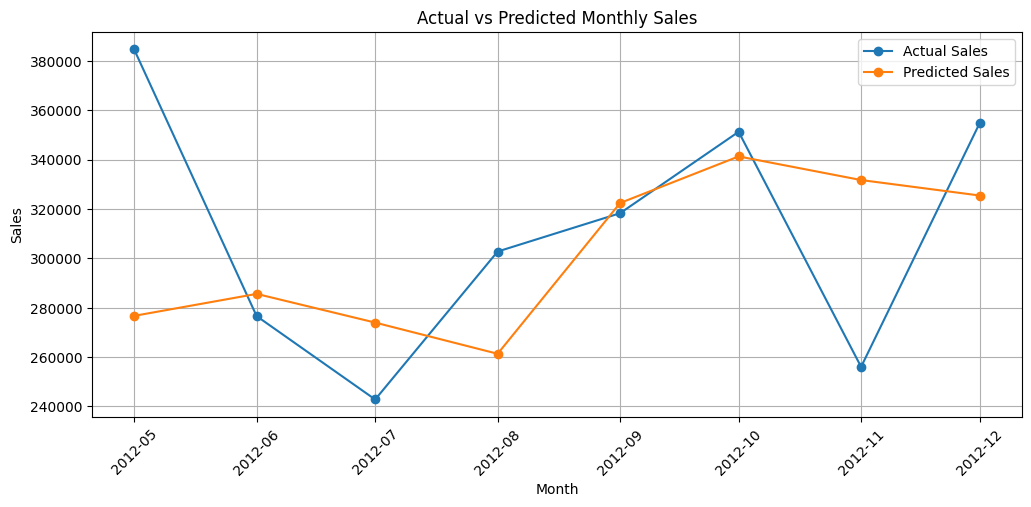

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_df["Order Date"].iloc[split_index:],
    y_test_v2.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    forecast_df["Order Date"].iloc[split_index:],
    y_pred_v2,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Create future dates
future_dates = pd.date_range(
    start="2013-01-01",
    periods=6,
    freq="MS"
)

future_predictions = []

# Copy historical monthly data
history = monthly_sales[["Order Date", "Sales"]].copy()

for date in future_dates:

    lag_1 = history["Sales"].iloc[-1]
    lag_3 = history["Sales"].iloc[-3]
    lag_12 = history["Sales"].iloc[-12]

    rolling_3 = history["Sales"].iloc[-3:].mean()

    month = date.month
    quarter = date.quarter

    future_input = pd.DataFrame({
        "lag_1": [lag_1],
        "lag_3": [lag_3],
        "lag_12": [lag_12],
        "rolling_3": [rolling_3],
        "Month": [month],
        "Quarter": [quarter]
    })

    prediction = forecast_model_v2.predict(future_input)[0]

    future_predictions.append(prediction)

    # Add prediction to history for next month's prediction
    history = pd.concat([
        history,
        pd.DataFrame({
            "Order Date": [date],
            "Sales": [prediction]
        })
    ], ignore_index=True)

future_sales = pd.DataFrame({
    "Month": future_dates,
    "Predicted Sales": future_predictions
})

future_sales

,Month,Predicted Sales
0,2013-01-01,285863.176860
1,2013-02-01,290397.623338
2,2013-03-01,282611.999773
3,2013-04-01,288964.332358
4,2013-05-01,264516.341683
5,2013-06-01,257104.960983


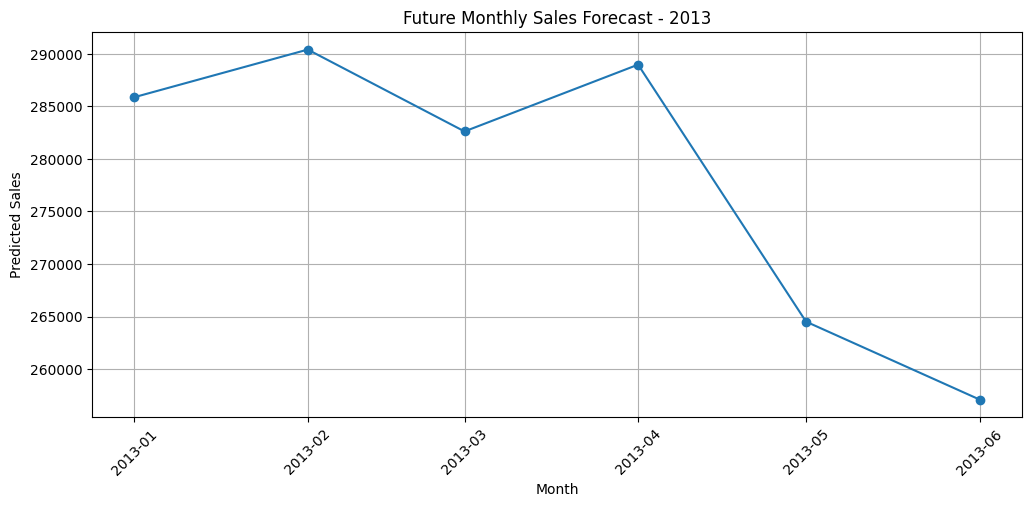

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    future_sales["Month"],
    future_sales["Predicted Sales"],
    marker="o"
)

plt.title("Future Monthly Sales Forecast - 2013")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
future_sales.to_csv("future_sales_predictions.csv", index=False)

print("Future predictions saved successfully!")

Future predictions saved successfully!


In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 69.8 MB/s eta 0:00:00


stream lit dashboard


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Retail Sales Dashboard",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Retail Sales Analysis & Future Sales Prediction")

st.write(
    "Interactive dashboard for analyzing historical retail sales "
    "and viewing future sales predictions."
)

# Load dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/valiotti/plotly-superstore/main/superstore.csv"
)

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Basic metrics
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

col1, col2, col3 = st.columns(3)

col1.metric("Total Sales", f"${total_sales:,.0f}")
col2.metric("Total Profit", f"${total_profit:,.0f}")
col3.metric("Total Orders", f"{total_orders:,}")

st.divider()

# Monthly sales
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

st.subheader("📈 Monthly Sales Trend")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.set_title("Monthly Sales Trend")
ax.grid(True)

st.pyplot(fig)

# Category sales
st.subheader("🏷️ Sales by Product Category")

category_sales = (
    df.groupby("Product Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

st.bar_chart(category_sales)

# Future predictions
st.subheader("🔮 Future Sales Prediction")

try:
    future_sales = pd.read_csv("future_sales_predictions.csv")
    future_sales["Month"] = pd.to_datetime(future_sales["Month"])

    st.dataframe(
        future_sales,
        use_container_width=True
    )

    fig2, ax2 = plt.subplots(figsize=(12, 5))

    ax2.plot(
        future_sales["Month"],
        future_sales["Predicted Sales"],
        marker="o"
    )

    ax2.set_xlabel("Month")
    ax2.set_ylabel("Predicted Sales")
    ax2.set_title("2013 Future Sales Forecast")
    ax2.grid(True)

    st.pyplot(fig2)

except FileNotFoundError:
    st.warning("Future prediction file not found.")

st.success("Dashboard loaded successfully!")

Writing app.py


In [ ]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 83.6 MB/s eta 0:00:00


In [ ]:
!streamlit --version

Streamlit, version 1.65.0


In [ ]:
import os

print("app.py exists:", os.path.exists("app.py"))

app.py exists: False


In [ ]:
import os

print("future_sales_predictions.csv exists:",
      os.path.exists("future_sales_predictions.csv"))

future_sales_predictions.csv exists: False


In [ ]:
import pandas as pd

future_sales = pd.DataFrame({
    "Month": pd.to_datetime([
        "2013-01-01",
        "2013-02-01",
        "2013-03-01",
        "2013-04-01",
        "2013-05-01",
        "2013-06-01"
    ]),
    "Predicted Sales": [
        285863.176860,
        290397.623338,
        282611.999773,
        288964.332358,
        264516.341683,
        257104.960983
    ]
})

future_sales.to_csv("future_sales_predictions.csv", index=False)

print("Future prediction file recreated successfully!")

Future prediction file recreated successfully!


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Retail Sales Dashboard",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Retail Sales Analysis & Future Sales Prediction")

st.write(
    "Interactive dashboard for historical retail sales analysis "
    "and future sales prediction."
)

# Load retail dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/valiotti/plotly-superstore/main/superstore.csv"
)

df["Order Date"] = pd.to_datetime(df["Order Date"])

# -----------------------------
# Key Metrics
# -----------------------------

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

col1, col2, col3 = st.columns(3)

col1.metric("Total Sales", f"${total_sales:,.0f}")
col2.metric("Total Profit", f"${total_profit:,.0f}")
col3.metric("Total Orders", f"{total_orders:,}")

st.divider()

# -----------------------------
# Monthly Sales Trend
# -----------------------------

st.subheader("📈 Monthly Sales Trend")

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.set_title("Monthly Sales Trend")
ax.grid(True)

st.pyplot(fig)

# -----------------------------
# Sales by Category
# -----------------------------

st.subheader("🏷️ Sales by Product Category")

category_sales = (
    df.groupby("Product Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

st.bar_chart(category_sales)

# -----------------------------
# Future Sales Prediction
# -----------------------------

st.subheader("🔮 Future Sales Prediction")

future_sales = pd.read_csv("future_sales_predictions.csv")

future_sales["Month"] = pd.to_datetime(future_sales["Month"])

st.dataframe(
    future_sales,
    use_container_width=True
)

fig2, ax2 = plt.subplots(figsize=(12, 5))

ax2.plot(
    future_sales["Month"],
    future_sales["Predicted Sales"],
    marker="o"
)

ax2.set_xlabel("Month")
ax2.set_ylabel("Predicted Sales")
ax2.set_title("2013 Future Sales Forecast")
ax2.grid(True)

st.pyplot(fig2)

st.success("Dashboard loaded successfully!")

Writing app.py


In [ ]:
import os

print("app.py:", os.path.exists("app.py"))
print("future_sales_predictions.csv:", os.path.exists("future_sales_predictions.csv"))

app.py: True
future_sales_predictions.csv: True


In [ ]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0



2026-10-05 18:54:02.032 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.229.113.221:8501

  Stopping...


In [ ]:

import os

print(os.path.exists("app.py"))
print(os.path.exists("future_sales_predictions.csv"))

True
True


In [ ]:
from google.colab import files

files.download("app.py")
files.download("future_sales_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>